# Sélection des Variables (Features)

1. Chargement et vérification des données

In [1]:
import pandas as pd

df = pd.read_csv("/content/donnees_pretraitees.csv")

print(df.head())

# Vérification (types de données et valeurs manquantes)
print(df.info())


             DateTemps  PuissanceActive (kW)  VitesseVent (m/s)  \
0  2017-01-07 00:00:00                6118.0                9.3   
1  2017-01-07 00:15:00                6066.0                9.3   
2  2017-01-07 00:30:00                6087.0                9.2   
3  2017-01-07 00:45:00                6486.0                9.3   
4  2017-01-07 01:00:00                7233.0               10.0   

   PuissanceThéorique  DirectionVent (°)  Annee  Mois  Jour  Heure  Minute  \
0                6000               60.0   2017     1     7      0       0   
1                6000               60.0   2017     1     7      0      15   
2                6000               60.0   2017     1     7      0      30   
3                6000               60.0   2017     1     7      0      45   
4                6768               60.0   2017     1     7      1       0   

   JourNuit  Saison  Temperature (°C)  deviation  deviation_percentage  \
0         1       1              9.90       30.0      

2. Analyse de Corrélation

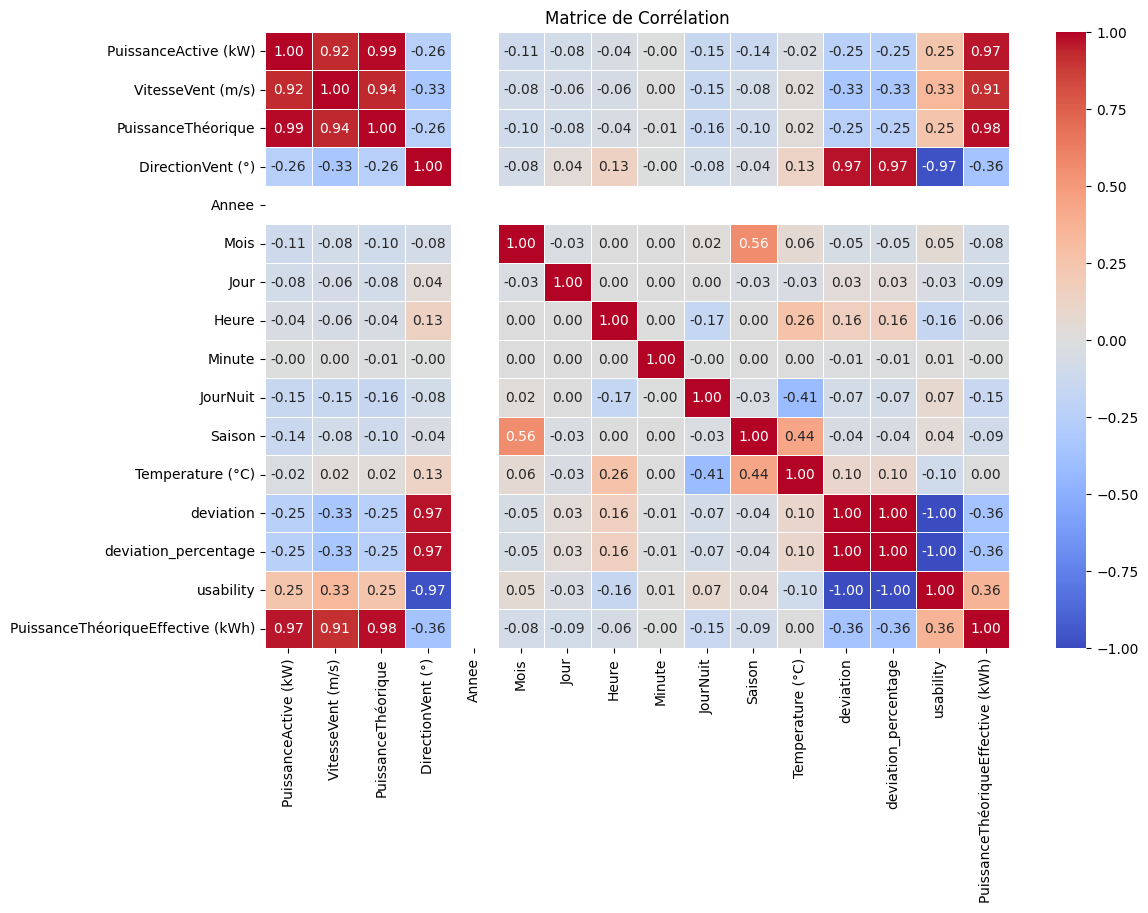

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner toutes les colonnes sauf 'DateTemps'
columns_to_include = df.drop(columns=['DateTemps']).select_dtypes(include=['number']).columns

# Calcule de la matrice de corrélation
corr = df[columns_to_include].corr()

# Visualisation (heatmap)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt='.2f', linewidths=0.5)
plt.title("Matrice de Corrélation")
plt.show()

**Conclusion:**
Tant que:
La corrélation entre (PuissanceActive (kW)) et (PuissanceThéorique) est de 0.99
et
La corrélation entre (PuissanceActive (kW)) et  (PuissanceThéoriqueEffective (kWh)) est de 0.97,

il existe une forte redondance d'information.

Donc:

- Cette redondance peut poser problème, car le modèle pourrait être influencé de manière incorrecte par des informations répétées.

- Étant donné que ces puissances théoriques ne donnent pas de nouvelles informations importantes pour prédire la puissance active, il est mieux de ne pas les utiliser dans le modèle. Cela permet d'avoir un modèle plus fiable et plus précis.

3. Analyse de l’Importance des Variables (Features)

3.1 Prétraitement des données

In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Suppression des colonnes inutiles
df = df.drop(columns=['DateTemps', 'PuissanceThéorique', 'PuissanceThéoriqueEffective (kWh)'])

# Sélection des colonnes numériques
numerical_columns = df.select_dtypes(include=['number']).columns

# Définir X (features) et y (target = PuissanceActive (kW))
y = df['PuissanceActive (kW)']
X = df[numerical_columns].drop(columns=['PuissanceActive (kW)'])

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

3.2 Importance des variables selon Random Forest

                 Feature  Importance
0      VitesseVent (m/s)    0.986747
9       Temperature (°C)    0.006183
8                 Saison    0.002680
1      DirectionVent (°)    0.001280
4                   Jour    0.000855
5                  Heure    0.000614
3                   Mois    0.000385
12             usability    0.000338
11  deviation_percentage    0.000331
10             deviation    0.000294
6                 Minute    0.000154
7               JourNuit    0.000138
2                  Annee    0.000000


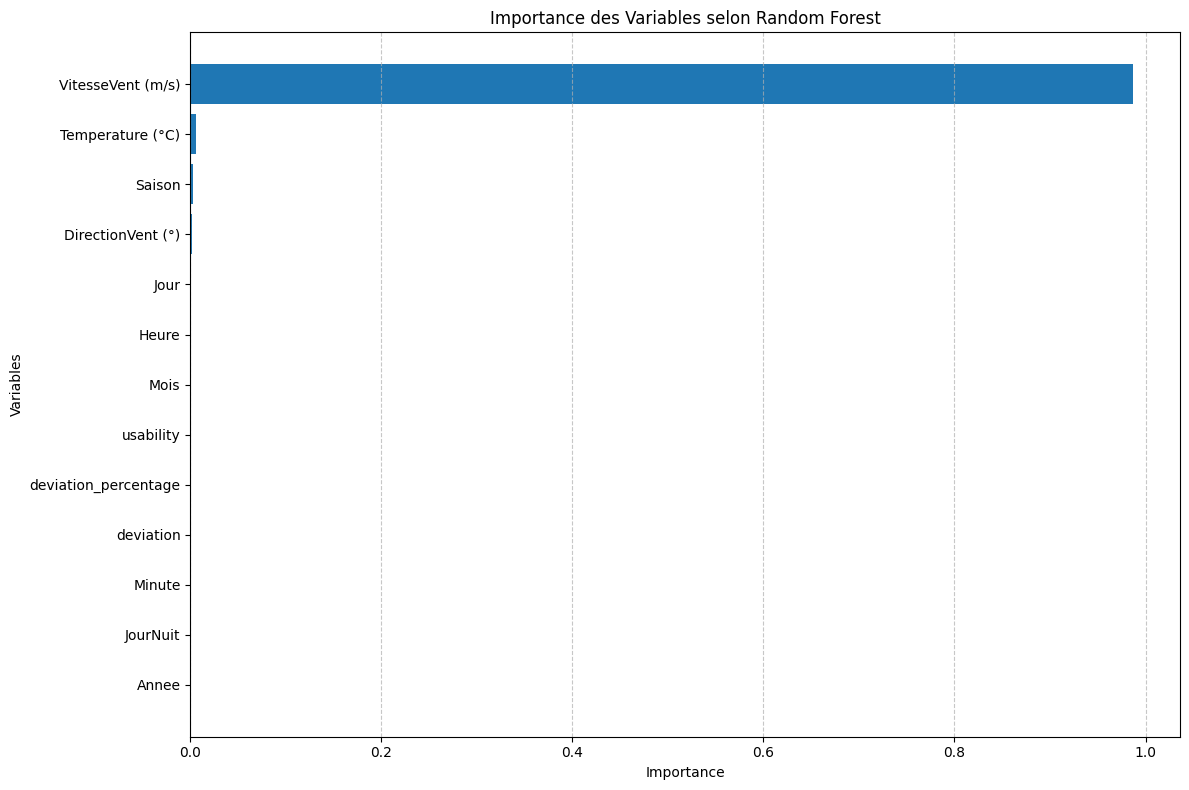

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Entraînement du modèle Random Forest
model = RandomForestRegressor(n_estimators=10, random_state=42)
model.fit(X_scaled, y)

# Récupération des importances et construction du DataFrame
importances = model.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)  # Trie


# Visualisation
print(rf_importance_df)

plt.figure(figsize=(12, 8))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Importance des Variables selon Random Forest')
plt.gca().invert_yaxis()  # Trie
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

3.4 Importance par permutation (Permutation Importance)

                 Feature  Importance
0      VitesseVent (m/s)    1.983955
9       Temperature (°C)    0.011727
8                 Saison    0.006428
1      DirectionVent (°)    0.003126
4                   Jour    0.001467
5                  Heure    0.000787
3                   Mois    0.000661
12             usability    0.000477
10             deviation    0.000434
11  deviation_percentage    0.000422
7               JourNuit    0.000263
6                 Minute    0.000190
2                  Annee    0.000000


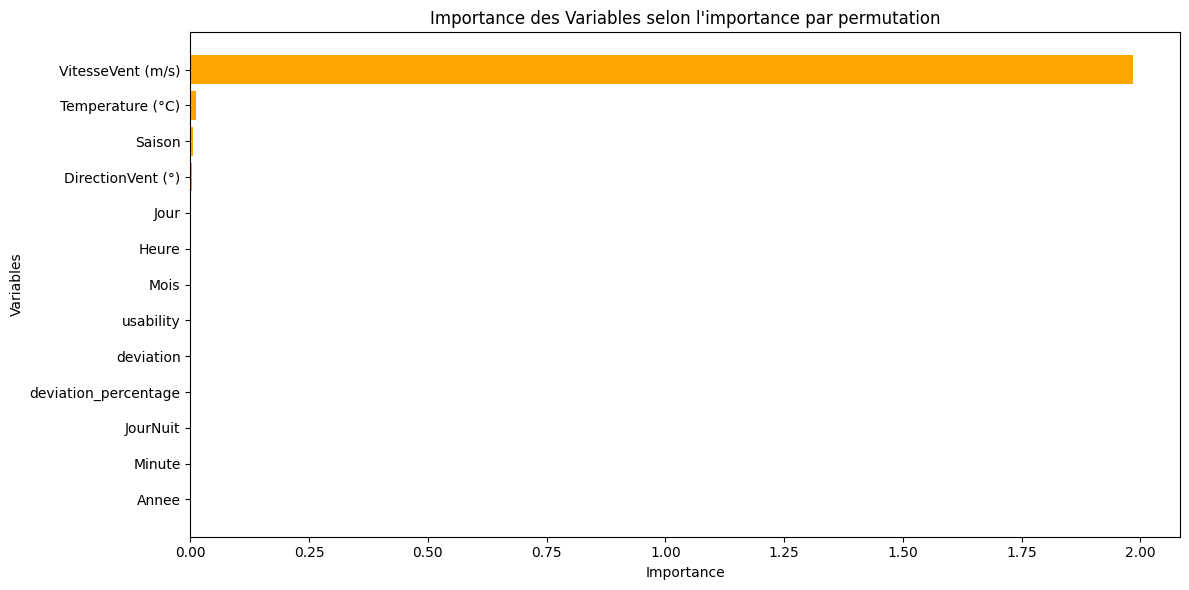

In [5]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

# Calcul de l'importance par permutation
perm_result = permutation_importance(model, X_scaled, y, n_repeats=10, random_state=42, scoring='r2')

# Création d'un DataFrame
perm_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_result.importances_mean
}).sort_values(by='Importance', ascending=False)


# Visualisation
print(perm_importance_df)

# Visualisation sans écart type
plt.figure(figsize=(12, 6))
plt.barh(perm_importance_df['Feature'], perm_importance_df['Importance'], color="orange")
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Importance des Variables selon l\'importance par permutation')
plt.tight_layout()
plt.show()

3.5 Comparaison Random Forest vs. Permutation Importance

                      Random Forest  Permutation
VitesseVent (m/s)          0.986747     1.983955
Temperature (°C)           0.006183     0.011727
Saison                     0.002680     0.006428
DirectionVent (°)          0.001280     0.003126
Jour                       0.000855     0.001467
Heure                      0.000614     0.000787
Mois                       0.000385     0.000661
usability                  0.000338     0.000477
deviation                  0.000294     0.000434
deviation_percentage       0.000331     0.000422
JourNuit                   0.000138     0.000263
Minute                     0.000154     0.000190
Annee                      0.000000     0.000000


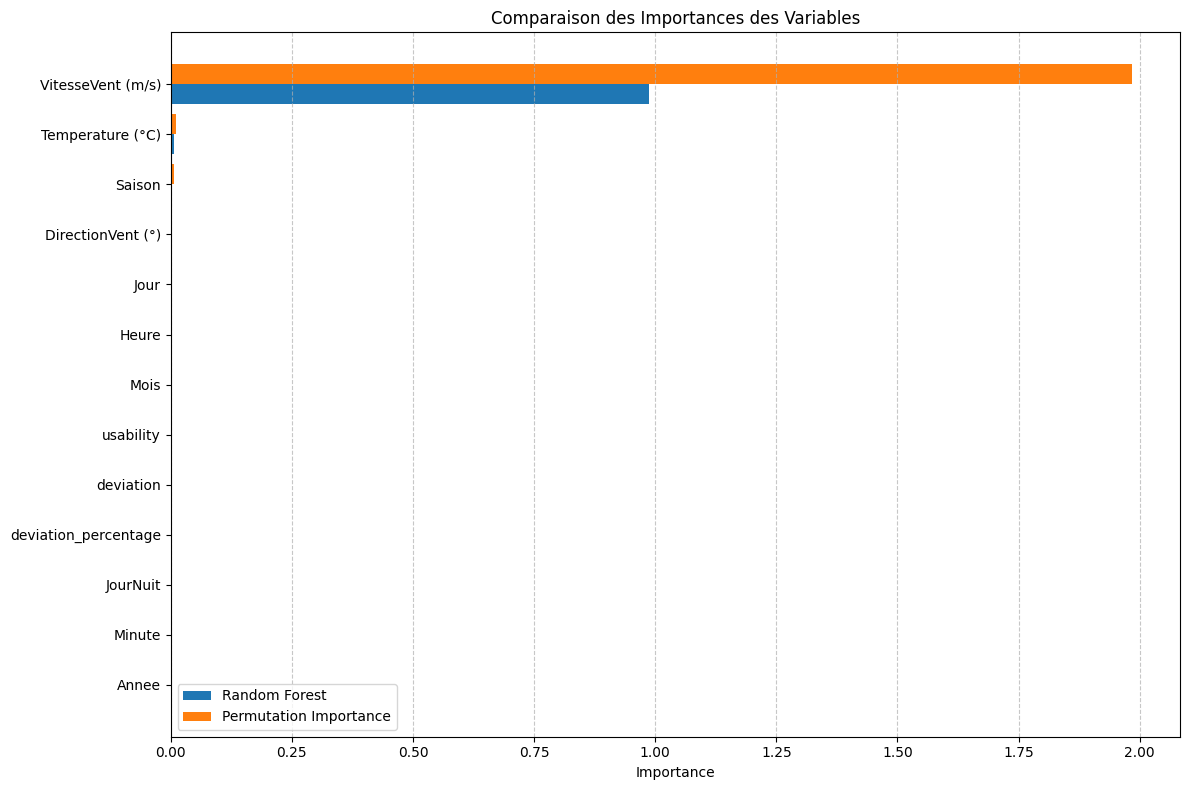

In [6]:
# Séries triées pour comparaison
perm_importance = pd.Series(perm_result.importances_mean, index=X.columns)
rf_importance = pd.Series(model.feature_importances_, index=X.columns)

# Fusion
comparison_df = pd.DataFrame({
    'Random Forest': rf_importance,
    'Permutation': perm_importance
}).sort_values(by='Permutation', ascending=False)


#Visualisation

print(comparison_df)

importance_df = comparison_df.sort_values(by='Permutation', ascending=True) #Trie

plt.figure(figsize=(12, 8))
bar_width = 0.4
index = range(len(importance_df))

plt.barh([i - bar_width/2 for i in index], importance_df['Random Forest'], height=bar_width, label='Random Forest')
plt.barh([i + bar_width/2 for i in index], importance_df['Permutation'], height=bar_width, label='Permutation Importance')

plt.yticks(index, importance_df.index)
plt.xlabel("Importance")
plt.title("Comparaison des Importances des Variables")
plt.legend()
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


# Découpage des données

1. Découpage des données

- Les données sont triées en fonction de la colonne DateTemps pour garantir qu'elles sont ordonnées par date.

- Les données sont séparées en quatre sous-ensembles, chacun correspondant à une saison spécifique (Hiver, Printemps, Été, Automne).

- Pour chaque saison, les données sont divisées en trois ensembles : train, validation, et test, avec un découpage de 70% pour l'entraînement, 10% pour la validation et 20% pour le test.

Remarque : [Les 70% pour l'entraînement viennent de la première division (test_size=0.3), La deuxième division de 66% pour le test et 34% pour la validation]

- Les sous-ensembles train, validation et test de chaque saison sont recombinés pour créer les ensembles finaux.

In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/donnees_pretraitees.csv")

# Trier les données par ordre chronologique
df = df.sort_values(by="DateTemps")

# Diviser les données par saison numérique
df_hiver = df[df['Saison'] == 1]  # Hiver
df_printemps = df[df['Saison'] == 2]  # Printemps
df_ete = df[df['Saison'] == 3]  # Été
df_automne = df[df['Saison'] == 4]  # Automne

# Découper chaque saison en train, validation et test (70% train, 10% val, 20% test)
train_hiver, temp_hiver = train_test_split(df_hiver, test_size=0.3, shuffle=False)
val_hiver, test_hiver = train_test_split(temp_hiver, test_size=0.66, shuffle=False)

train_printemps, temp_printemps = train_test_split(df_printemps, test_size=0.3, shuffle=False)
val_printemps, test_printemps = train_test_split(temp_printemps, test_size=0.66, shuffle=False)

train_ete, temp_ete = train_test_split(df_ete, test_size=0.3, shuffle=False)
val_ete, test_ete = train_test_split(temp_ete, test_size=0.66, shuffle=False)

train_automne, temp_automne = train_test_split(df_automne, test_size=0.3, shuffle=False)
val_automne, test_automne = train_test_split(temp_automne, test_size=0.66, shuffle=False)

# Combiner les sous-ensembles pour créer l'ensemble final
train = pd.concat([train_hiver, train_printemps, train_ete, train_automne])
val = pd.concat([val_hiver, val_printemps, val_ete, val_automne])
test = pd.concat([test_hiver, test_printemps, test_ete, test_automne])


# Vérification des tailles
print(f"Taille du train : {len(train)}")
print(f"Taille du validation : {len(val)}")
print(f"Taille du test : {len(test)}")


Taille du train : 24123
Taille du validation : 3515
Taille du test : 6826


2. Vérification de la distribution des saisons dans les ensembles

In [8]:
print("Répartition des saisons dans l'ensemble d'entraînement :")
print(train['Saison'].value_counts())

print("Répartition des saisons dans l'ensemble de validation :")
print(val['Saison'].value_counts())

print("Répartition des saisons dans l'ensemble de test :")
print(test['Saison'].value_counts())


Répartition des saisons dans l'ensemble d'entraînement :
Saison
2    6182
3    6182
4    6115
1    5644
Name: count, dtype: int64
Répartition des saisons dans l'ensemble de validation :
Saison
2    901
3    901
4    891
1    822
Name: count, dtype: int64
Répartition des saisons dans l'ensemble de test :
Saison
2    1749
3    1749
4    1730
1    1598
Name: count, dtype: int64


3. Vérification

In [9]:
print(df.head())

             DateTemps  PuissanceActive (kW)  VitesseVent (m/s)  \
0  2017-01-07 00:00:00                6118.0                9.3   
1  2017-01-07 00:15:00                6066.0                9.3   
2  2017-01-07 00:30:00                6087.0                9.2   
3  2017-01-07 00:45:00                6486.0                9.3   
4  2017-01-07 01:00:00                7233.0               10.0   

   PuissanceThéorique  DirectionVent (°)  Annee  Mois  Jour  Heure  Minute  \
0                6000               60.0   2017     1     7      0       0   
1                6000               60.0   2017     1     7      0      15   
2                6000               60.0   2017     1     7      0      30   
3                6000               60.0   2017     1     7      0      45   
4                6768               60.0   2017     1     7      1       0   

   JourNuit  Saison  Temperature (°C)  deviation  deviation_percentage  \
0         1       1              9.90       30.0      

4. Sauvegarde des ensembles dans des fichiers CSV

In [10]:
import pandas as pd
from google.colab import files

# Supprimer les colonnes indésirables
cols_to_drop = ['PuissanceThéorique', 'PuissanceThéoriqueEffective (kWh)']
train = train.drop(columns=cols_to_drop)
val = val.drop(columns=cols_to_drop)
test = test.drop(columns=cols_to_drop)

# Enregistrer les fichiers CSV
train.to_csv("/content/donnees_train.csv", index=False)
val.to_csv("/content/donnees_val.csv", index=False)
test.to_csv("/content/donnees_test.csv", index=False)

# Télécharger les fichiers
files.download("/content/donnees_train.csv")
files.download("/content/donnees_val.csv")
files.download("/content/donnees_test.csv")

print(f"Les ensembles sont bien sauvegardés")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Les ensembles sont bien sauvegardés


# Analyse statistique et visualisation de la répartition des données après le split

1. Comparaison des statistiques (moyenne, écart-type, min, max)

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Chargement des fichiers
train_df = pd.read_csv("/content/donnees_train.csv")
val_df = pd.read_csv("/content/donnees_val.csv")
test_df = pd.read_csv("/content/donnees_test.csv")

# Définir les colonnes
target_column = "PuissanceActive (kW)"
feature_columns = ['VitesseVent (m/s)', 'DirectionVent (°)', 'Temperature (°C)',
                   'Saison', 'Annee', 'Mois', 'Jour', 'Heure', 'Minute','JourNuit',
                   'deviation', 'deviation_percentage', 'usability']

# Convertir en tableaux numpy
#Features
train_X = train_df[feature_columns].values
val_X = val_df[feature_columns].values
test_X = test_df[feature_columns].values

# La cible
train_y = train_df[target_column].values
val_y = val_df[target_column].values
test_y = test_df[target_column].values

# Comparaison des statistiques
def compare_statistics(train_X, val_X, test_X, feature_columns):
    print("Comparaison des statistiques pour chaque feature :")
    for i, feature in enumerate(feature_columns):
        print(f"\n--- {feature} ---")
        print(f"Train : mean={train_X[:, i].mean():.2f}, std={train_X[:, i].std():.2f}, min={train_X[:, i].min():.2f}, max={train_X[:, i].max():.2f}")
        print(f"Val   : mean={val_X[:, i].mean():.2f}, std={val_X[:, i].std():.2f}, min={val_X[:, i].min():.2f}, max={val_X[:, i].max():.2f}")
        print(f"Test  : mean={test_X[:, i].mean():.2f}, std={test_X[:, i].std():.2f}, min={test_X[:, i].min():.2f}, max={test_X[:, i].max():.2f}")

# Exécution
compare_statistics(train_X, val_X, test_X, feature_columns)


Comparaison des statistiques pour chaque feature :

--- VitesseVent (m/s) ---
Train : mean=5.91, std=2.85, min=0.00, max=19.61
Val   : mean=5.09, std=2.66, min=0.00, max=13.51
Test  : mean=5.17, std=2.45, min=0.00, max=16.00

--- DirectionVent (°) ---
Train : mean=119.09, std=101.68, min=10.00, max=360.00
Val   : mean=169.24, std=117.76, min=10.00, max=360.00
Test  : mean=122.23, std=111.07, min=10.00, max=360.00

--- Temperature (°C) ---
Train : mean=26.82, std=10.43, min=-0.10, max=48.50
Val   : mean=27.45, std=11.05, min=4.60, max=46.90
Test  : mean=25.20, std=12.47, min=-0.10, max=47.90

--- Saison ---
Train : mean=2.53, std=1.11, min=1.00, max=4.00
Val   : mean=2.53, std=1.11, min=1.00, max=4.00
Test  : mean=2.53, std=1.11, min=1.00, max=4.00

--- Annee ---
Train : mean=2017.00, std=0.00, min=2017.00, max=2017.00
Val   : mean=2017.00, std=0.00, min=2017.00, max=2017.00
Test  : mean=2017.00, std=0.00, min=2017.00, max=2017.00

--- Mois ---
Train : mean=5.63, std=3.17, min=1.00, max

2. Visualisation des distributions des variables (Train / Validation / Test)

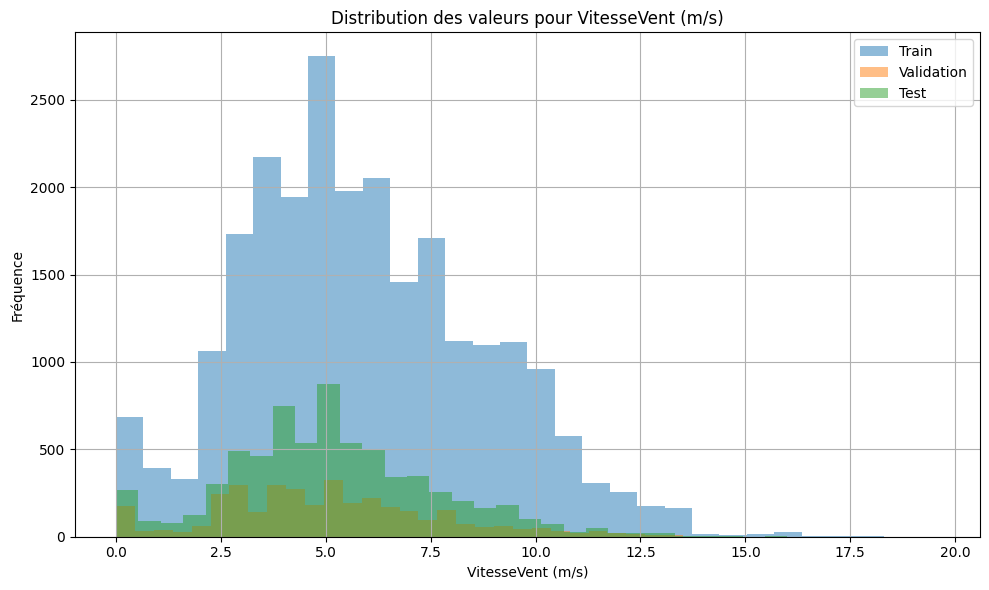

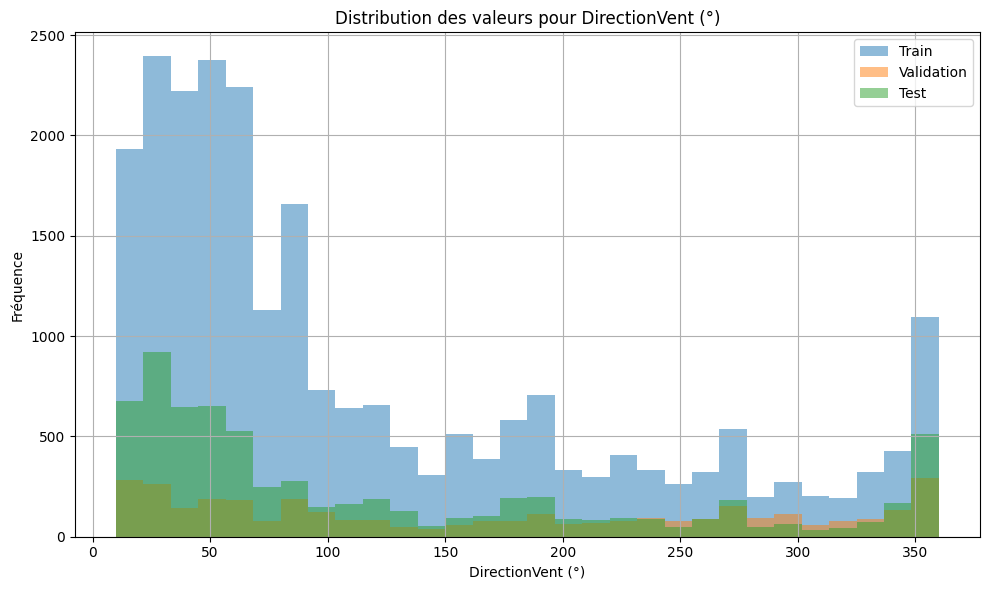

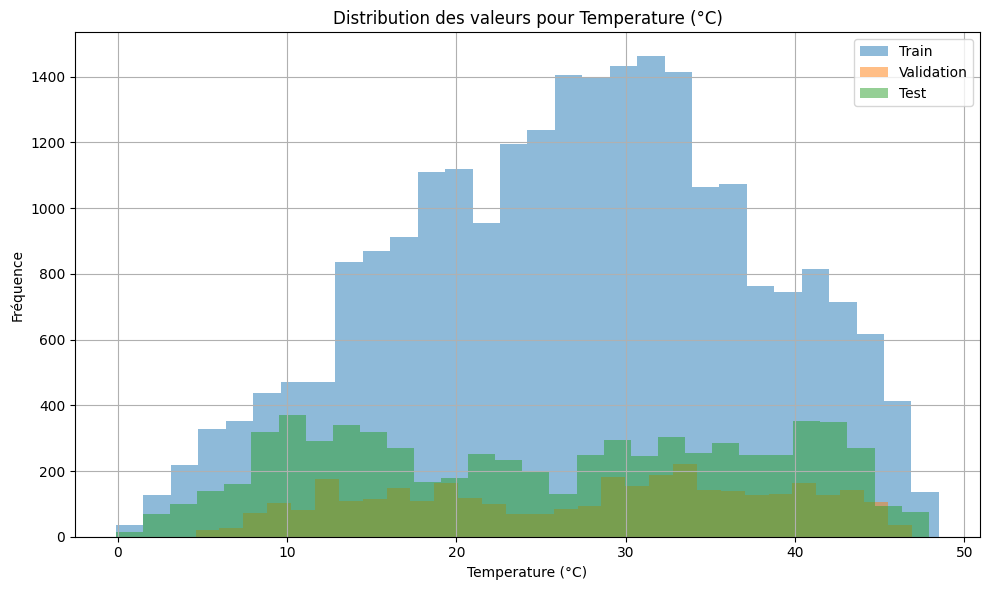

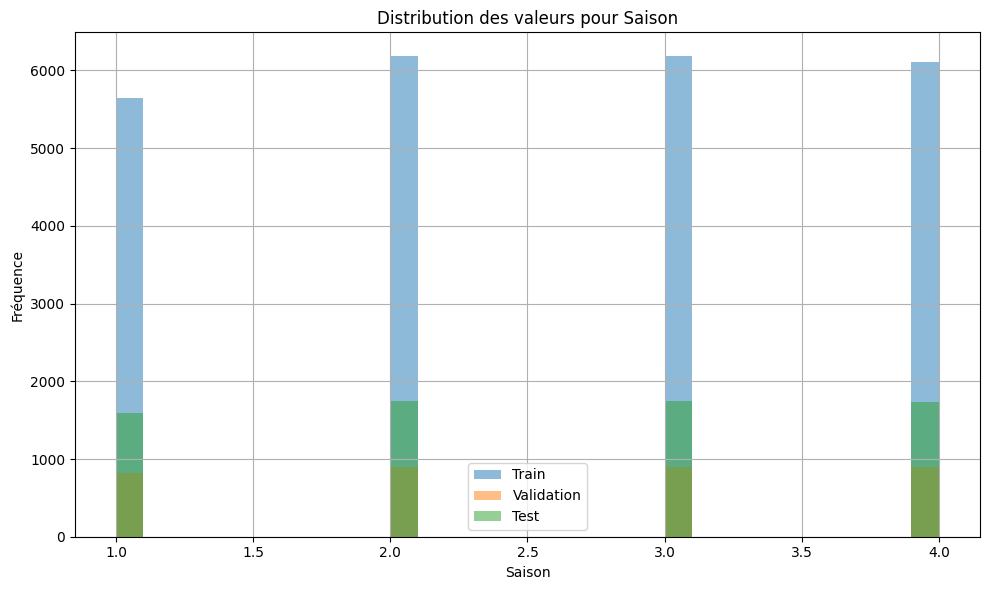

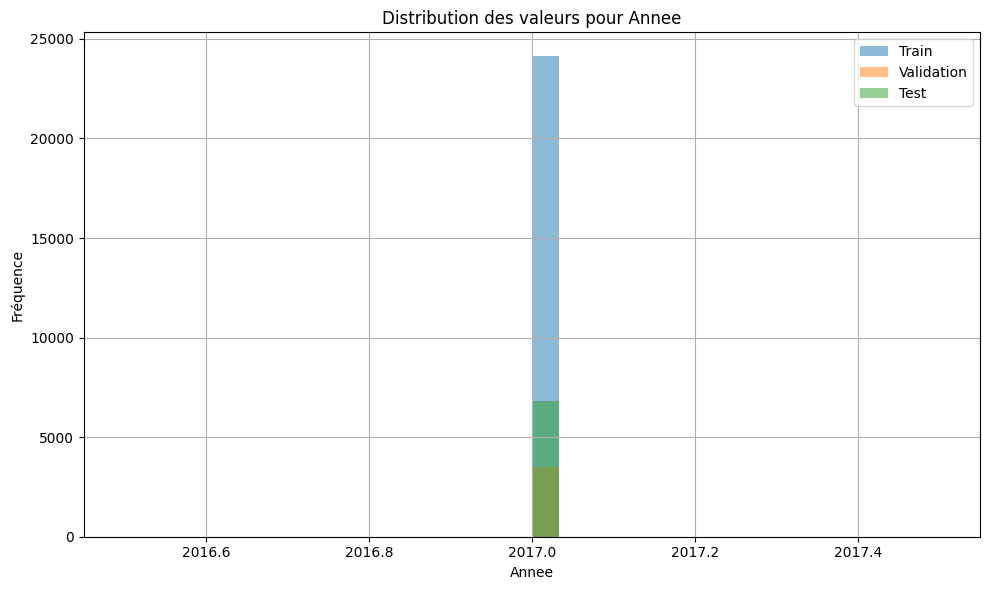

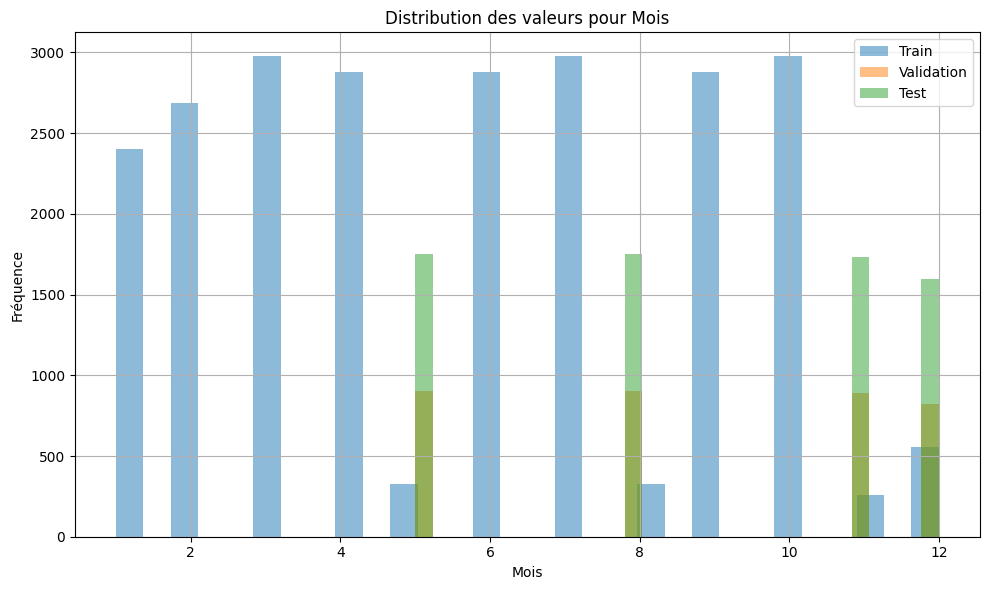

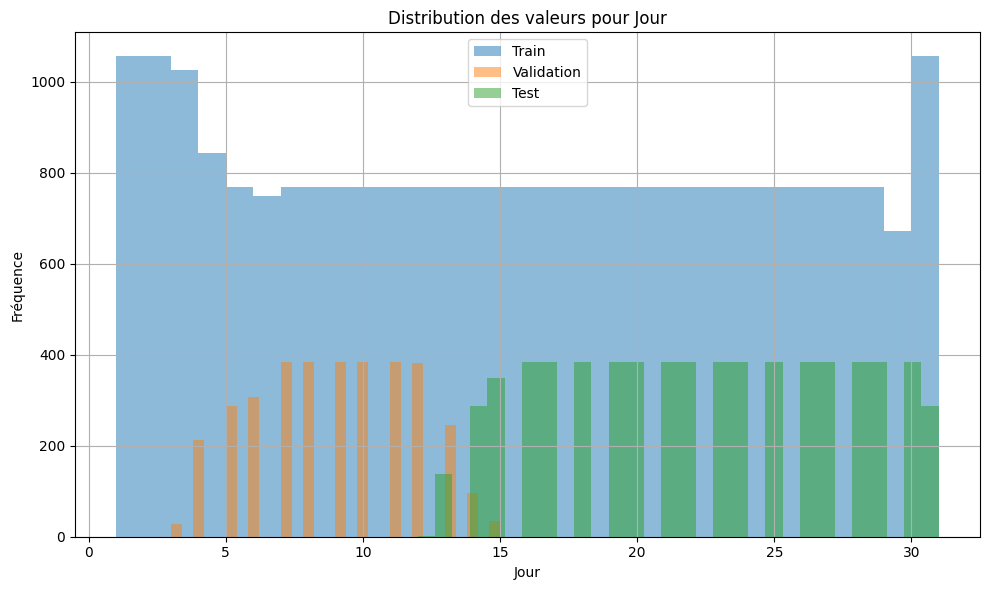

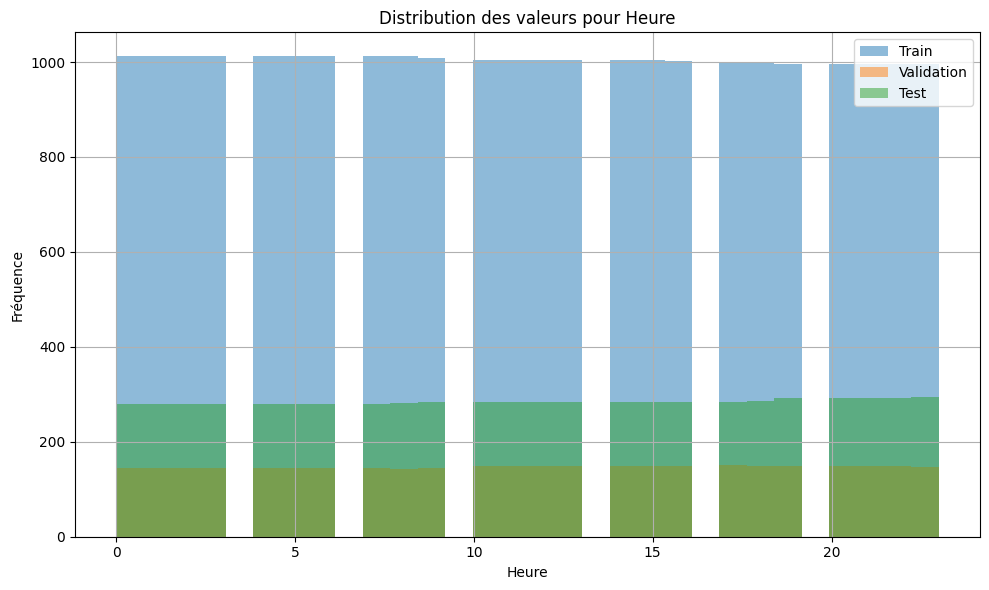

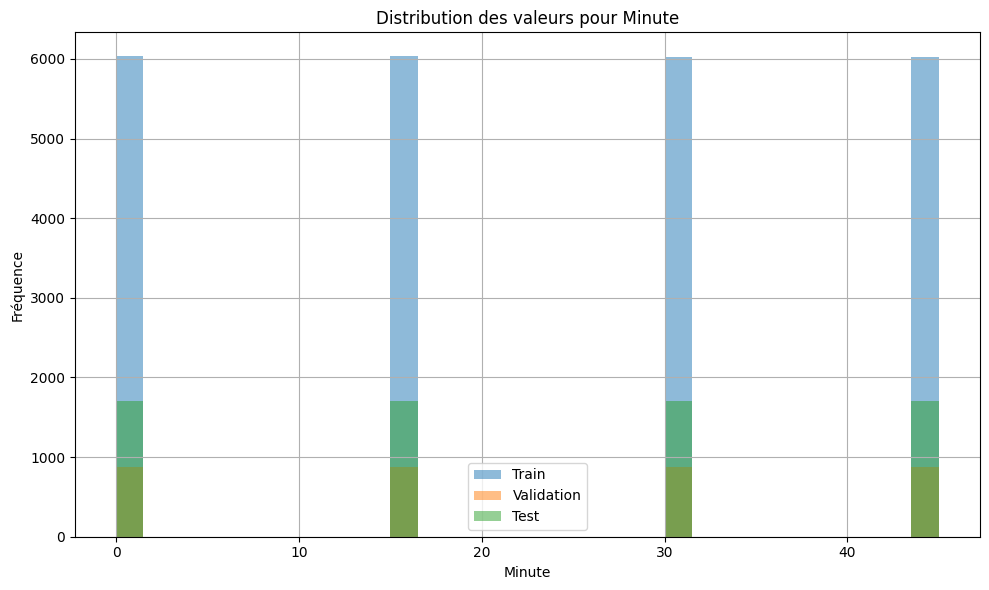

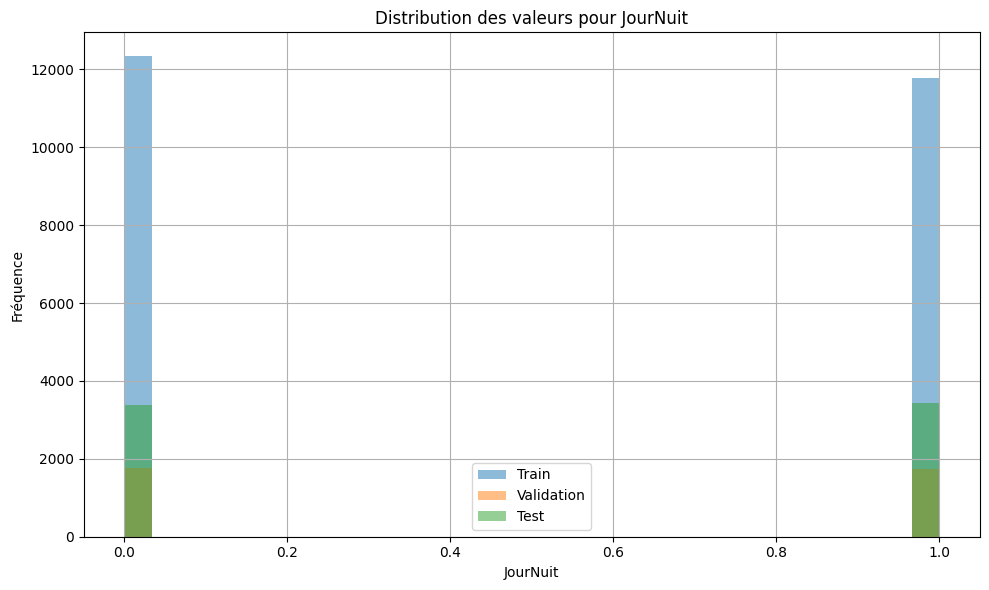

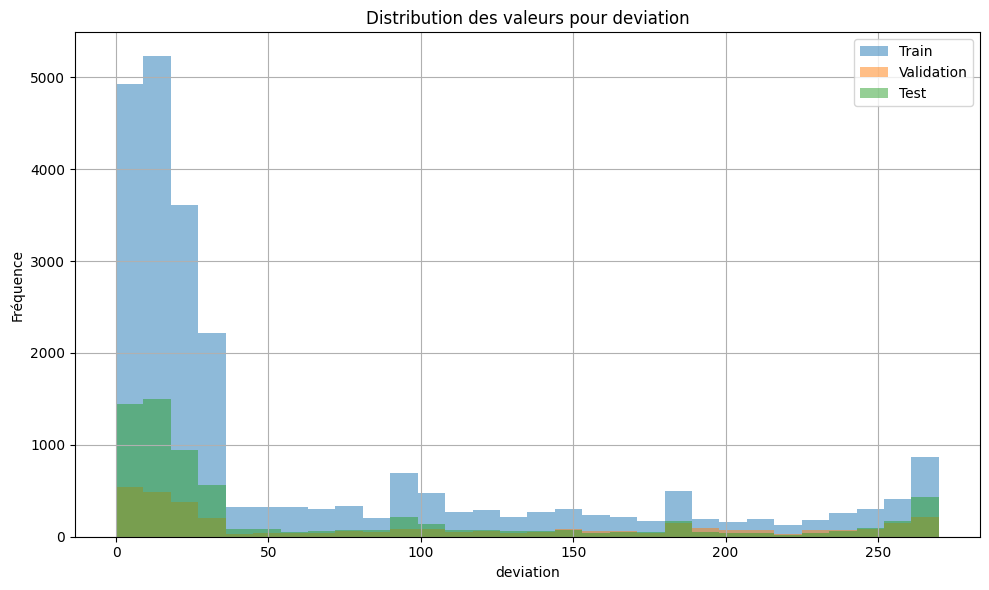

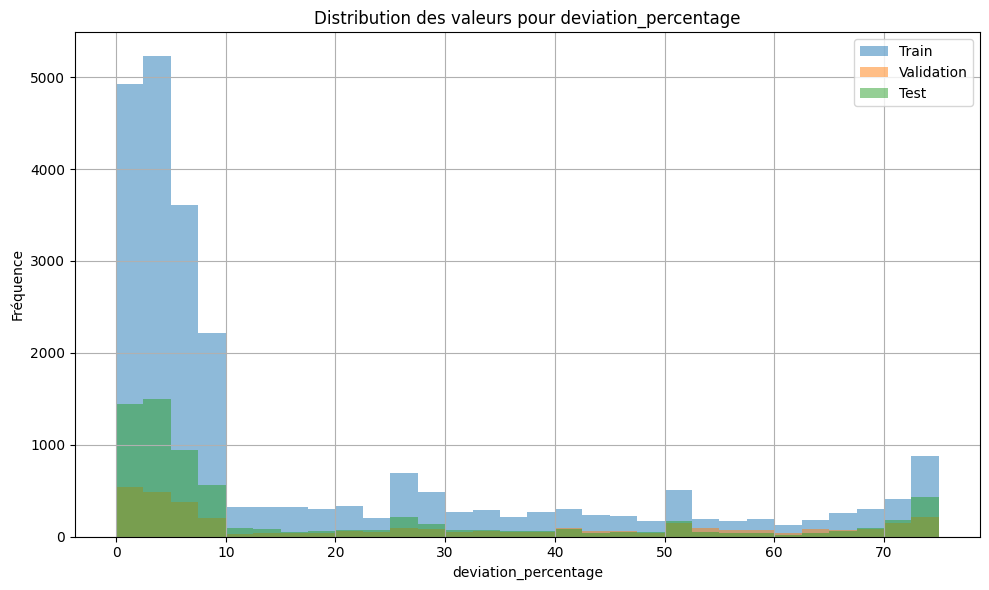

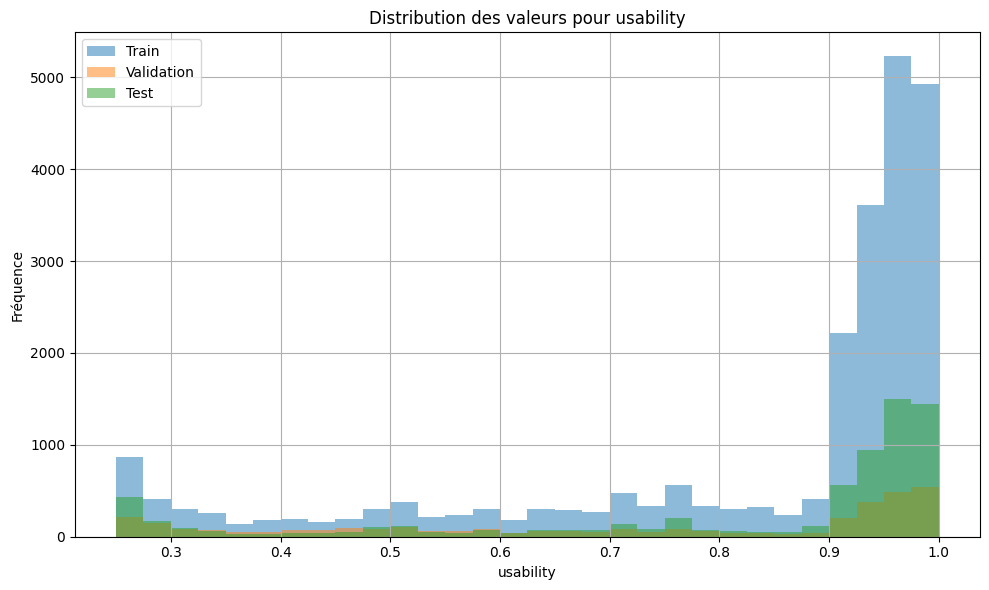

In [12]:
def plot_distributions(train_X, val_X, test_X, feature_columns):
    for i, feature in enumerate(feature_columns):
        plt.figure(figsize=(10, 6))
        plt.hist(train_X[:, i], bins=30, alpha=0.5, label='Train')
        plt.hist(val_X[:, i], bins=30, alpha=0.5, label='Validation')
        plt.hist(test_X[:, i], bins=30, alpha=0.5, label='Test')
        plt.title(f"Distribution des valeurs pour {feature}")
        plt.xlabel(feature)
        plt.ylabel("Fréquence")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_distributions(train_X, val_X, test_X, feature_columns)

3. Comparaison des statistiques (moyenne, écart-type, min, max) de la variable cible : PuissanceActive (kW)

In [13]:
def compare_target_statistics(train_y, val_y, test_y, target_column):
    print(f"\n Statistiques de la variable cible : {target_column}\n")
    print(f"Train : mean={np.mean(train_y):.2f}, std={np.std(train_y):.2f}, min={np.min(train_y):.2f}, max={np.max(train_y):.2f}")
    print(f"Val   : mean={np.mean(val_y):.2f}, std={np.std(val_y):.2f}, min={np.min(val_y):.2f}, max={np.max(val_y):.2f}")
    print(f"Test  : mean={np.mean(test_y):.2f}, std={np.std(test_y):.2f}, min={np.min(test_y):.2f}, max={np.max(test_y):.2f}")

# Exécution
compare_target_statistics(train_y, val_y, test_y, target_column)


 Statistiques de la variable cible : PuissanceActive (kW)

Train : mean=2125.98, std=2451.82, min=0.00, max=10200.00
Val   : mean=1512.25, std=2062.29, min=0.00, max=9696.14
Test  : mean=1451.86, std=1866.52, min=0.00, max=10200.00


4. Visualiation de la distribution de la variable cible : PuissanceActive (kW)

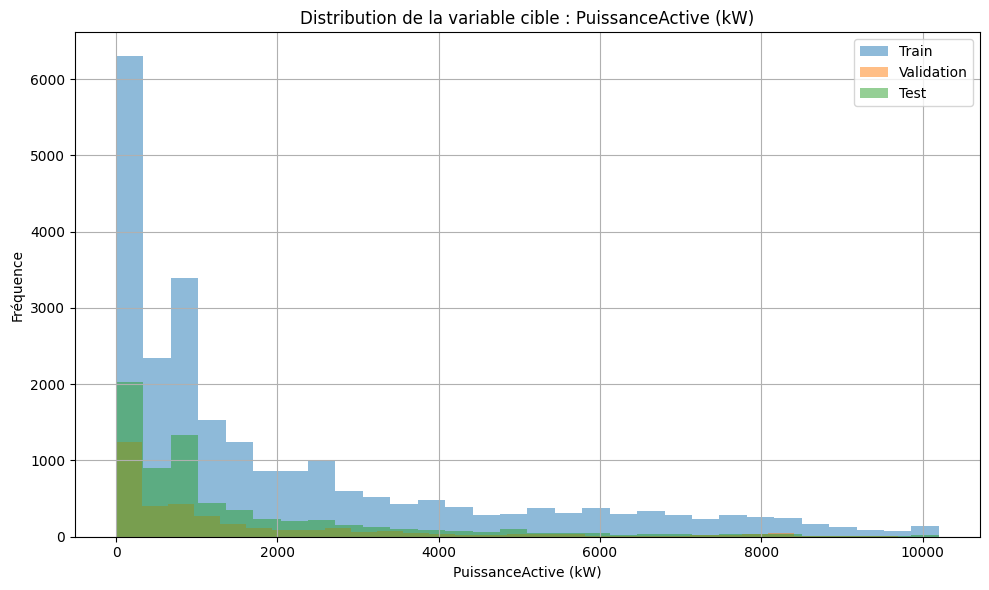

In [14]:
plt.figure(figsize=(10, 6))
plt.hist(train_y, bins=30, alpha=0.5, label='Train')
plt.hist(val_y, bins=30, alpha=0.5, label='Validation')
plt.hist(test_y, bins=30, alpha=0.5, label='Test')
plt.title("Distribution de la variable cible : PuissanceActive (kW)")
plt.xlabel("PuissanceActive (kW)")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

5. Répartition de la variable cible pour l’ensemble Train + Validation et Test (Diagramme circulaire)

Répartition des plages de puissance pour Train + Validation :
 - Basse (<1000 kW)       : 13834 (50.05%)
 - Moyenne (1000-8000 kW) : 12719 (46.02%)
 - Haute (>=8000 kW)      : 1085 (3.93%)

Répartition des plages de puissance pour Test :
 - Basse (<1000 kW)       : 4181 (61.25%)
 - Moyenne (1000-8000 kW) : 2540 (37.21%)
 - Haute (>=8000 kW)      : 105 (1.54%)



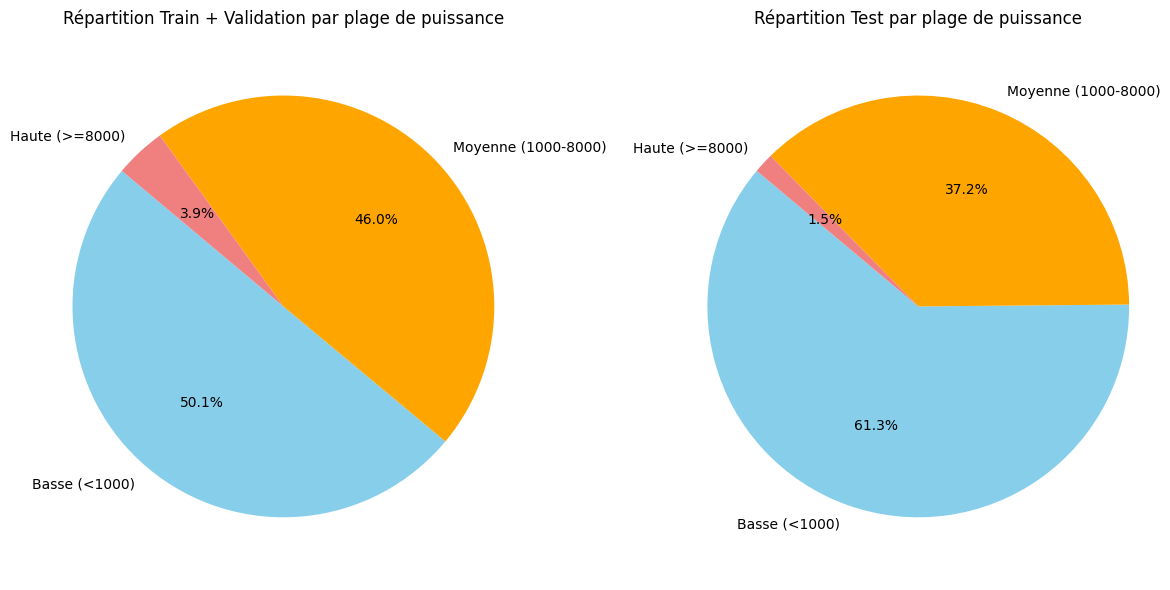

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Fusionner train et validation
df_train_val = pd.concat([train_df, val_df], ignore_index=True)

# La colonne cible
target_column = "PuissanceActive (kW)"

# Fonctions pour calculer les plages et afficher texte + Diagramme circulaire
def compute_and_plot(df, label):
    plage_basse = df[target_column] < 1000
    plage_moyenne = (df[target_column] >= 1000) & (df[target_column] < 8000)
    plage_haute = df[target_column] >= 8000

    nb_basse = plage_basse.sum()
    nb_moyenne = plage_moyenne.sum()
    nb_haute = plage_haute.sum()
    total = len(df)

    print(f"Répartition des plages de puissance pour {label} :")
    print(f" - Basse (<1000 kW)       : {nb_basse} ({(nb_basse / total) * 100:.2f}%)")
    print(f" - Moyenne (1000-8000 kW) : {nb_moyenne} ({(nb_moyenne / total) * 100:.2f}%)")
    print(f" - Haute (>=8000 kW)      : {nb_haute} ({(nb_haute / total) * 100:.2f}%)")
    print()

    sizes = [nb_basse, nb_moyenne, nb_haute]
    colors = ['skyblue', 'orange', 'lightcoral']
    labels = ['Basse (<1000)', 'Moyenne (1000-8000)', 'Haute (>=8000)']

    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
    plt.title(f"Répartition {label} par plage de puissance")
    plt.axis('equal')

# # Figure avec 2 sous-graphes
plt.figure(figsize=(12, 6))

# Graphe Train + Val
plt.subplot(1, 2, 1)
compute_and_plot(df_train_val, "Train + Validation")

# Graphe Test
plt.subplot(1, 2, 2)
compute_and_plot(test_df, "Test")

plt.tight_layout()
plt.show()